# Customer Churn Prediction Analysis

## Codveda Technologies Internship Project

### Project Objective
The aim of this project is to analyze customer behavior and predict customer churn using telecom customer data.

Customer churn refers to customers leaving or discontinuing a service. This project uses data analysis and machine learning techniques to identify factors influencing churn.

In [6]:
# Importing necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading the Dataset

I load the training and testing datasets into Google Colab for analysis and modeling.

In [7]:
import pandas as pd
train_data = pd.read_csv('/content/drive/MyDrive/churn-bigml-80.csv')
test_data = pd.read_csv('/content/drive/MyDrive/churn-bigml-20.csv')

In [ ]:
# Display first 5 rows

train_data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
##Checking Dataset Shape

print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

Training Dataset Shape: (2666, 20)
Testing Dataset Shape: (667, 20)


In [ ]:
## Viewing all column names in the dataset.

import pandas as pd
train_data = pd.read_csv('/content/drive/MyDrive/churn-bigml-80.csv')
train_data.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [ ]:
## Checking data types and identifying missing values.

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [ ]:
train_data.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [15]:
X_train.dtypes


,0
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64
Total eve calls,int64


In [16]:
X_train.select_dtypes(include=['object']).columns

Index(['International plan', 'Voice mail plan'], dtype='object')

In [ ]:
train_data.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


# Data Cleaning

Converting categorical values into numerical format for machine learning analysis.

In [ ]:
# Convert churn column to integer

test_data = pd.read_csv('/content/drive/MyDrive/churn-bigml-20.csv')
train_data['Churn'] = train_data['Churn'].astype(int)
test_data['Churn'] = test_data['Churn'].astype(int)

train_data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [17]:
# Initialize label encoder

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Columns to encode

columns_to_encode = ['International plan', 'Voice mail plan']

for column in columns_to_encode:
    train_data[column] = encoder.fit_transform(train_data[column])
    test_data[column] = encoder.transform(test_data[column])

train_data.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [11]:
# Remove State column

train_data = train_data.drop(columns=['State'], errors='ignore')
test_data = test_data.drop(columns=['State'], errors='ignore')

In [12]:
train_data.columns

Index(['Account length', 'Area code', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')

# Preparing Data for Machine Learning

Separating features and target variables for model training and testing.

In [18]:
# Features

X_train = train_data.drop('Churn', axis=1)
X_test = test_data.drop('Churn', axis=1)

# Target

y_train = train_data['Churn']
y_test = test_data['Churn']

# Customer Churn Distribution

Analyzing the number of customers who churned and those who stayed.

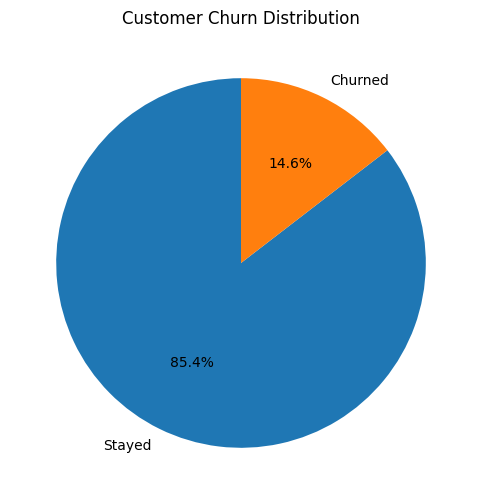

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution pie chart

churn_counts = train_data['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Churn Distribution')

plt.show()

### Insight

The visualization shows that the majority of customers did not churn, while a smaller percentage of customers left the service. This indicates that customer retention is relatively stable, although churn still represents a significant business concern.

# Exploratory Data Analysis (EDA)

Exploring patterns, trends, and relationships within the dataset.

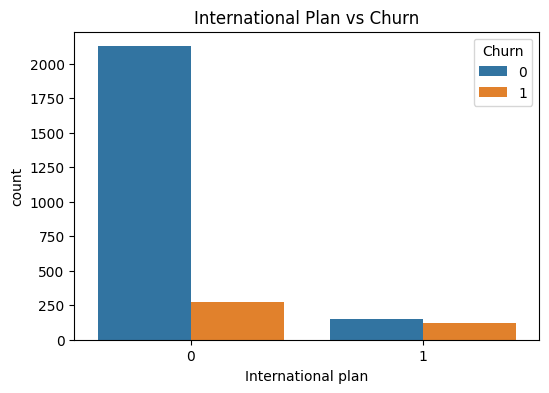

In [ ]:
### International Plan vs Churn

## Analyzing whether customers with international plans are more likely to churn.


plt.figure(figsize=(6,4))

sns.countplot(x='International plan', hue='Churn', data=train_data)

plt.title('International Plan vs Churn')

plt.show()

### Insight

Customers with international plans appeared more likely to churn compared to customers without international plans. This may suggest that international service users experience higher dissatisfaction or pricing concerns.

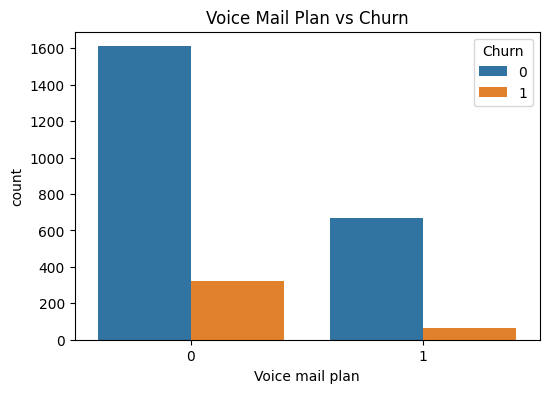

In [ ]:
### Voice Mail Plan vs Churn

## Analyzing the relationship between voice mail plans and customer churn.


plt.figure(figsize=(6,4))

sns.countplot(x='Voice mail plan', hue='Churn', data=train_data)

plt.title('Voice Mail Plan vs Churn')

plt.show()

### Insight

Customers without voice mail plans showed higher churn tendencies compared to customers with voice mail plans. This suggests that additional service features may contribute to customer retention.

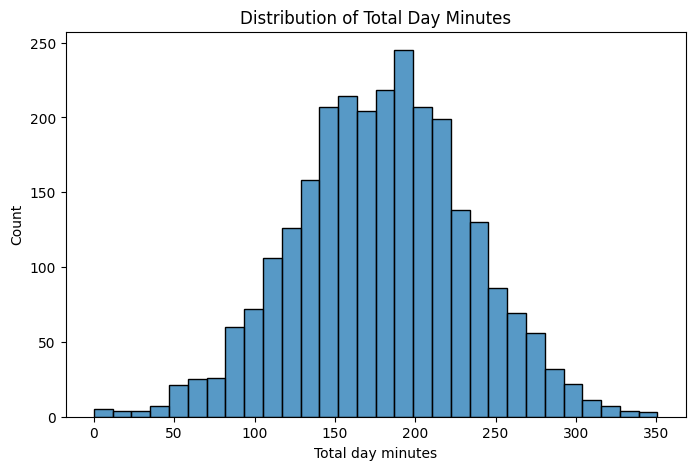

In [ ]:
## # Distribution of Total Day Minutes

## Analyzing customer daytime call usage patterns.


plt.figure(figsize=(8,5))

sns.histplot(train_data['Total day minutes'], bins=30)

plt.title('Distribution of Total Day Minutes')

plt.show()

### Insight

The distribution of total day minutes shows varying customer usage behaviors. Most customers fall within moderate usage ranges, while fewer customers have extremely high daytime call usage.

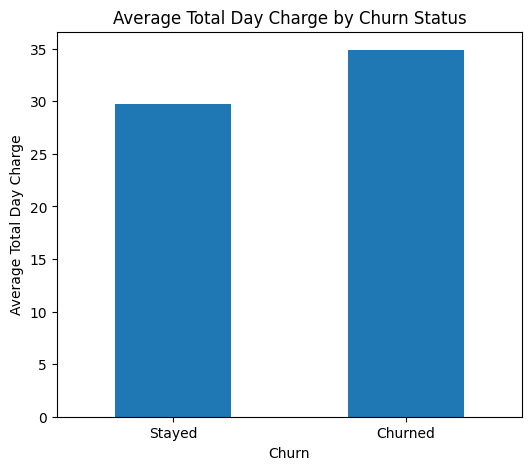

In [27]:
# Average total day charge by churn

average_charge = train_data.groupby('Churn')['Total day charge'].mean()

plt.figure(figsize=(6,5))

average_charge.plot(kind='bar')

plt.title('Average Total Day Charge by Churn Status')

plt.xlabel('Churn')
plt.ylabel('Average Total Day Charge')

plt.xticks([0,1], ['Stayed', 'Churned'], rotation=0)

plt.show()

### Insight

Customers who churned showed higher average total day charges compared to customers who stayed. This suggests that higher service costs may contribute to customer dissatisfaction and churn.

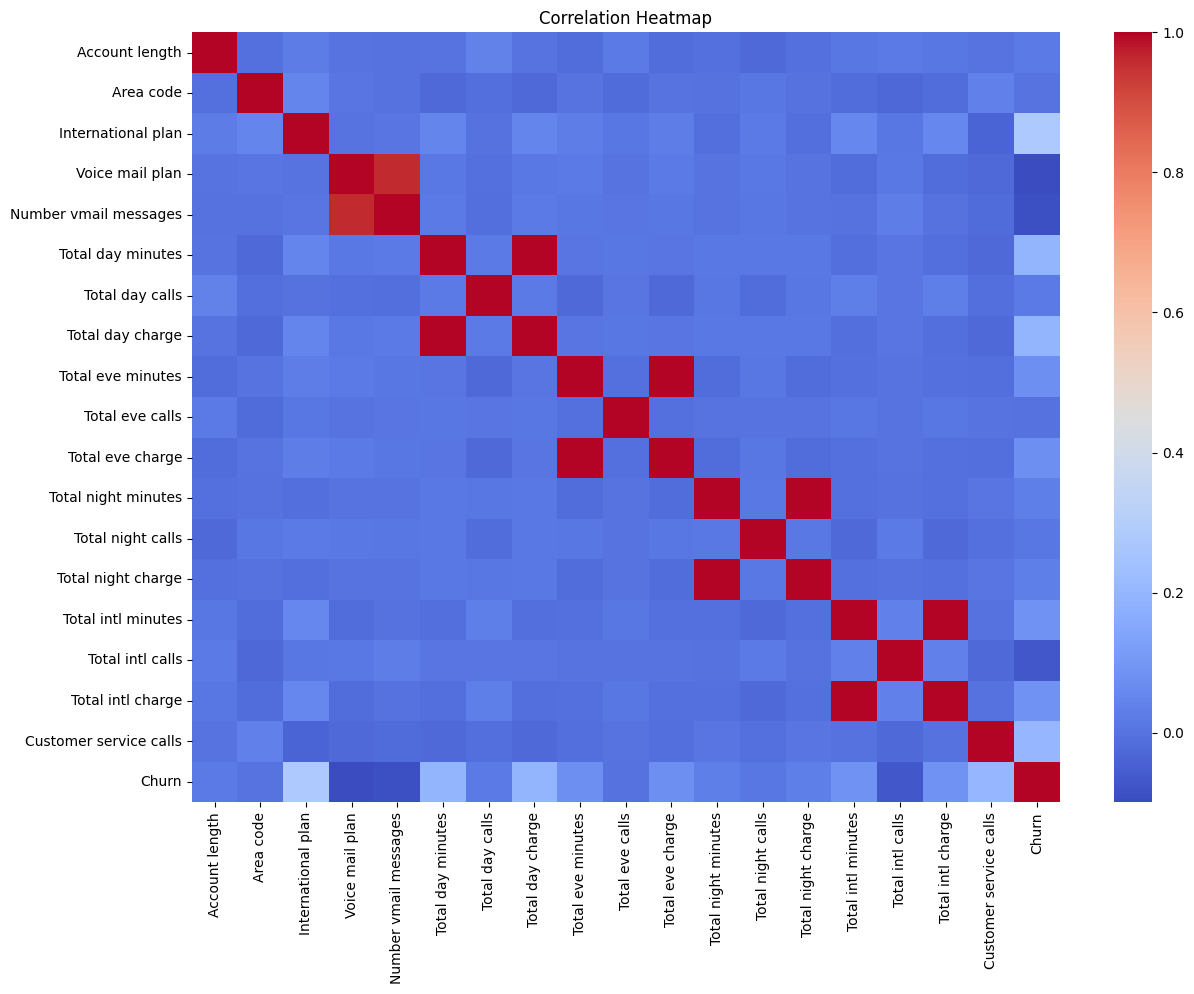

In [28]:
# Correlation Heatmap

## Visualizing correlations between numerical variables in the dataset.

plt.figure(figsize=(14,10))

sns.heatmap(
    train_data.corr(numeric_only=True),
    annot=False,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight

The heatmap shows relationships between numerical variables in the dataset. Variables related to customer usage and service charges displayed stronger relationships, suggesting that customer behavior and billing patterns may influence churn.

# Key Insights

- Customers with international plans showed higher churn tendencies.
- Higher day charges appeared to influence customer churn.
- Voice mail plans may contribute to customer retention.
- Customer usage behavior plays an important role in churn prediction.

# Preparing Data for Machine Learning

Separating features and target variables for model training and testing.

In [9]:
# Features

X_train = train_data.drop('Churn', axis=1)
X_test = test_data.drop('Churn', axis=1)

# Target

y_train = train_data['Churn']
y_test = test_data['Churn']

# Logistic Regression Model

Training a Logistic Regression model for customer churn prediction.

In [19]:
# Create model

model = LogisticRegression(max_iter=1000)

# Train model

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [25]:
#  Model Predictions
## Using the trained model to predict customer churn.

y_pred = model.predict(X_test)

In [21]:
## Model Evaluation
## Evaluating model performance using accuracy score.

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.856071964017991


### Insight

The Logistic Regression model achieved a good prediction accuracy, demonstrating its ability to identify customer churn patterns based on customer behavior and service usage data.

In [24]:
##CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[555  17]
 [ 79  16]]


### Insight

The confusion matrix shows the model's prediction performance by comparing actual customer churn outcomes with predicted outcomes. This helps evaluate the model’s effectiveness in correctly identifying churn cases.

# Classification Report

Displaying precision, recall, and F1-score of the model.

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.97      0.92       572
        True       0.48      0.17      0.25        95

    accuracy                           0.86       667
   macro avg       0.68      0.57      0.59       667
weighted avg       0.82      0.86      0.82       667



### Insight

The classification report provides detailed evaluation metrics including precision, recall, and F1-score. These metrics help measure the overall performance and reliability of the churn prediction model.

# Conclusion

This project analyzed customer behavior and developed a machine learning model to predict customer churn.

Key findings from the analysis include:
- Customers with international plans were more likely to churn.
- Higher service charges influenced customer retention.
- Customer usage behavior significantly affected churn patterns.

The Logistic Regression model successfully predicted customer churn with good accuracy, demonstrating the usefulness of data analytics and machine learning in solving real-world business problems.